In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import dask
import matplotlib.patches as patches
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import numpy as np

### Create Xarray Dataset from meltwater files and save as netCDF file

In [3]:
file_list = []
for file in os.listdir('/Volumes/insar3/cjensen/Data/MAR/ftp.climato.be/fettweis/MARv3.14/Greenland/CESM2-ssp370-10km-daily/'):
    if file[:3] == 'MAR' and file[27:-3] < '2026':
        file_list.append('/Volumes/insar3/cjensen/Data/MAR/ftp.climato.be/fettweis/MARv3.14/Greenland/CESM2-ssp370-10km-daily/'+file)

In [4]:
ds = xr.open_dataset(file_list[0])

In [5]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (y: 270, x: 150, SECTOR: 2, TIME: 365, SECTOR1_1: 1)
Coordinates:
  * y          (y) float32 1kB -3.348e+03 -3.338e+03 ... -667.9 -657.9
  * x          (x) float32 600B -640.0 -630.0 -620.0 ... 830.0 840.0 850.0
  * SECTOR     (SECTOR) float32 8B 1.0 2.0
  * TIME       (TIME) datetime64[ns] 3kB 2009-12-30T12:00:00 ... 2010-12-29T1...
  * SECTOR1_1  (SECTOR1_1) float32 4B 1.0
Data variables: (12/37)
    LON        (y, x) float32 162kB ...
    LAT        (y, x) float32 162kB ...
    SH         (y, x) float32 162kB ...
    SRF        (y, x) float32 162kB ...
    SOL        (y, x) float32 162kB ...
    MSK        (y, x) float32 162kB ...
    ...         ...
    SHF        (TIME, y, x) float32 59MB ...
    AL1        (TIME, SECTOR, y, x) float32 118MB ...
    AL2        (TIME, SECTOR, y, x) float32 118MB ...
    SP         (TIME, y, x) float32 59MB ...
    SLP        (TIME, y, x) float32 59MB ...
    crs        |S1 1B ...
Attributes:
    Conventions:  CF-1.6
    institute:    University of Liege (Belgium)
    contact:      xavier.fettweis@uliege.be
    model:        regional climate model MAR (v3.14.3)
    date:         Tue Nov 18 09:00:58 CET 2025

In [6]:
# def _decode_months(ds):
#     units = ds.time.attrs.get("units", "")
#     if "since" not in units:
#         return ds
#     base = pd.to_datetime(units.split("since", 1)[1].strip())
#     return ds.assign_coords(
#         time=("TIME", [base + pd.DateOffset(months=int(v)) for v in ds.time.values])
#     )

# sorted_files = sorted(file_list, key=lambda p: int(os.path.basename(p).split('-')[-1].split('.')[0]))

# def _decode_months(ds):
#     time_name = next((name for name in ds.coords if name.lower() == "time"), None)
#     if time_name is None:
#         return ds

#     units = ds.coords[time_name].attrs.get("units", "")
#     if "since" not in units:
#         return ds

#     base = pd.to_datetime(units.split("since", 1)[1].strip())
#     ds = ds.assign_coords(
#         {time_name: [base + pd.DateOffset(months=int(v)) for v in ds.coords[time_name].values]}
#     )
#     return ds

sorted_files = sorted(file_list, key=lambda p: int(os.path.basename(p).split('-')[-1].split('.')[0]))

meltwater = xr.open_mfdataset(
    sorted_files,
    # decode_times=False,
    # preprocess=_decode_months,
    combine="nested",
    concat_dim="TIME",
)

meltwater

/tmp/ipykernel_838633/2027993299.py:29: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  meltwater = xr.open_mfdataset(


<xarray.Dataset> Size: 61GB
Dimensions:    (TIME: 9490, y: 270, x: 150, SECTOR: 2, SECTOR1_1: 1)
Coordinates:
  * TIME       (TIME) datetime64[ns] 76kB 1999-12-30T12:00:00 ... 2025-12-28T...
  * y          (y) float32 1kB -3.348e+03 -3.338e+03 ... -667.9 -657.9
  * x          (x) float32 600B -640.0 -630.0 -620.0 ... 830.0 840.0 850.0
  * SECTOR     (SECTOR) float32 8B 1.0 2.0
  * SECTOR1_1  (SECTOR1_1) float32 4B 1.0
Data variables: (12/37)
    LON        (TIME, y, x) float32 2GB dask.array<chunksize=(365, 270, 150), meta=np.ndarray>
    LAT        (TIME, y, x) float32 2GB dask.array<chunksize=(365, 270, 150), meta=np.ndarray>
    SH         (TIME, y, x) float32 2GB dask.array<chunksize=(365, 270, 150), meta=np.ndarray>
    SRF        (TIME, y, x) float32 2GB dask.array<chunksize=(365, 270, 150), meta=np.ndarray>
    SOL        (TIME, y, x) float32 2GB dask.array<chunksize=(365, 270, 150), meta=np.ndarray>
    MSK        (TIME, y, x) float32 2GB dask.array<chunksize=(365, 270, 150), meta=np.ndarray>
    ...         ...
    SHF        (TIME, y, x) float32 2GB dask.array<chunksize=(1, 270, 150), meta=np.ndarray>
    AL1        (TIME, SECTOR, y, x) float32 3GB dask.array<chunksize=(1, 2, 270, 150), meta=np.ndarray>
    AL2        (TIME, SECTOR, y, x) float32 3GB dask.array<chunksize=(1, 2, 270, 150), meta=np.ndarray>
    SP         (TIME, y, x) float32 2GB dask.array<chunksize=(1, 270, 150), meta=np.ndarray>
    SLP        (TIME, y, x) float32 2GB dask.array<chunksize=(1, 270, 150), meta=np.ndarray>
    crs        (TIME) |S1 9kB b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
Attributes:
    Conventions:  CF-1.6
    institute:    University of Liege (Belgium)
    contact:      xavier.fettweis@uliege.be
    model:        regional climate model MAR (v3.14.3)
    date:         Tue Nov 18 08:49:52 CET 2025

In [7]:
ice_mask = meltwater['MSK'].isel(TIME=0).values > 0
meltwater_masked = meltwater['RU'].where(ice_mask)

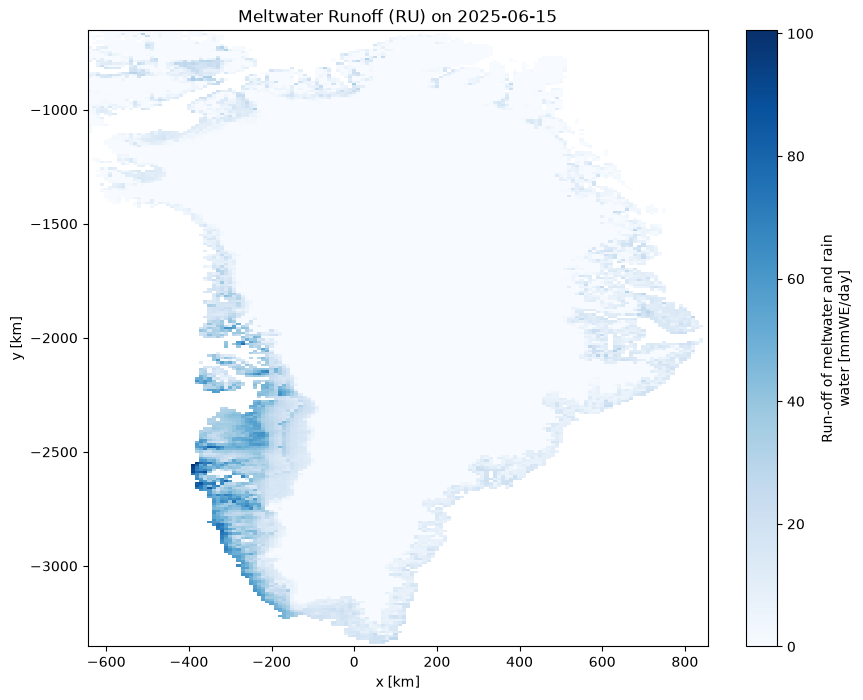

In [294]:
fig, ax = plt.subplots(figsize=(10, 8))
meltwater_masked.sel(TIME='2025-06-15', method='nearest').mean(dim='SECTOR').plot(
    ax=ax,
    cmap='Blues',
)
ax.set_title('Meltwater Runoff (RU) on 2025-06-15')
plt.show()

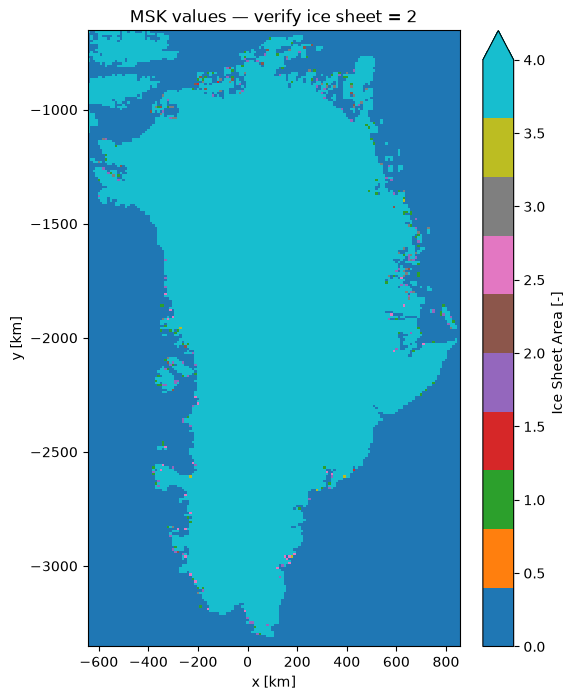

In [295]:
fig, ax = plt.subplots(figsize=(6, 8))
meltwater['MSK'].isel(TIME=0).plot(ax=ax, cmap='tab10', vmin=0, vmax=4)
plt.show()

In [314]:
meltwater['RU']

<xarray.DataArray 'RU' (TIME: 9490, SECTOR: 2, y: 270, x: 150)> Size: 3GB
dask.array<concatenate, shape=(9490, 2, 270, 150), dtype=float32, chunksize=(1, 2, 270, 150), chunktype=numpy.ndarray>
Coordinates:
  * TIME     (TIME) datetime64[ns] 76kB 1999-12-30T12:00:00 ... 2025-12-28T12...
  * SECTOR   (SECTOR) float32 8B 1.0 2.0
  * y        (y) float32 1kB -3.348e+03 -3.338e+03 -3.328e+03 ... -667.9 -657.9
  * x        (x) float32 600B -640.0 -630.0 -620.0 -610.0 ... 830.0 840.0 850.0
Attributes:
    long_name:     Run-off of meltwater and rain water
    units:         mmWE/day
    grid_mapping:  crs

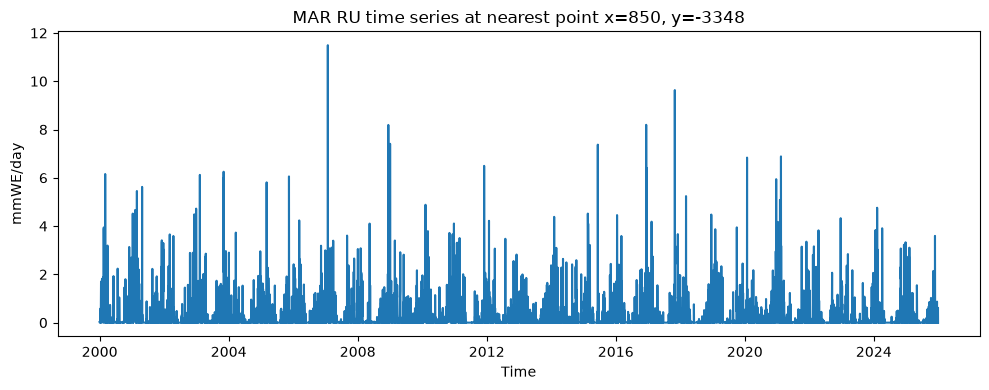

In [303]:
x_pt = 488900.158671
y_pt = -1098954.829477

nearest_x = meltwater.x.sel(x=x_pt, method="nearest").item()
nearest_y = meltwater.y.sel(y=y_pt, method="nearest").item()

ru_point = meltwater["RU"].sel(x=nearest_x, y=nearest_y, method="nearest")
ru_ts = ru_point.mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 4))
ru_ts.plot(ax=ax)

ax.set_title(
    f"MAR RU time series at nearest point x={nearest_x:.0f}, y={nearest_y:.0f}"
)
ax.set_ylabel(meltwater["RU"].attrs.get("units", ""))
ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

In [8]:
# bbox = {'minx': 451370.605, 'miny': -1133119.400, 'maxx': 510831.600, 'maxy': -1080000}
bbox = {'minx': 400, 'miny': -1220, 'maxx': 560, 'maxy': -980}
# box = [400000, 560000, -980000, -1150000]

In [9]:
xmin, xmax = bbox["minx"], bbox["maxx"]
ymin, ymax = bbox["miny"], bbox["maxy"]

# handle increasing or decreasing coordinate axes
x_coords = meltwater_masked.x.values
y_coords = meltwater_masked.y.values

xsel = (
    slice(xmax, xmin)
    if (x_coords.size and x_coords[0] > x_coords[-1])
    else slice(xmin, xmax)
)
ysel = slice(ymax, ymin) if (y_coords.size and y_coords[0] > y_coords[-1]) else slice(ymin, ymax)

meltwater_masked = meltwater.sel(x=xsel, y=ysel).assign_attrs(units="m")
meltwater_masked

<xarray.Dataset> Size: 620MB
Dimensions:    (TIME: 9490, y: 24, x: 17, SECTOR: 2, SECTOR1_1: 1)
Coordinates:
  * TIME       (TIME) datetime64[ns] 76kB 1999-12-30T12:00:00 ... 2025-12-28T...
  * y          (y) float32 96B -1.218e+03 -1.208e+03 ... -997.9 -987.9
  * x          (x) float32 68B 400.0 410.0 420.0 430.0 ... 540.0 550.0 560.0
  * SECTOR     (SECTOR) float32 8B 1.0 2.0
  * SECTOR1_1  (SECTOR1_1) float32 4B 1.0
Data variables: (12/37)
    LON        (TIME, y, x) float32 15MB dask.array<chunksize=(365, 24, 17), meta=np.ndarray>
    LAT        (TIME, y, x) float32 15MB dask.array<chunksize=(365, 24, 17), meta=np.ndarray>
    SH         (TIME, y, x) float32 15MB dask.array<chunksize=(365, 24, 17), meta=np.ndarray>
    SRF        (TIME, y, x) float32 15MB dask.array<chunksize=(365, 24, 17), meta=np.ndarray>
    SOL        (TIME, y, x) float32 15MB dask.array<chunksize=(365, 24, 17), meta=np.ndarray>
    MSK        (TIME, y, x) float32 15MB dask.array<chunksize=(365, 24, 17), meta=np.ndarray>
    ...         ...
    SHF        (TIME, y, x) float32 15MB dask.array<chunksize=(1, 24, 17), meta=np.ndarray>
    AL1        (TIME, SECTOR, y, x) float32 31MB dask.array<chunksize=(1, 2, 24, 17), meta=np.ndarray>
    AL2        (TIME, SECTOR, y, x) float32 31MB dask.array<chunksize=(1, 2, 24, 17), meta=np.ndarray>
    SP         (TIME, y, x) float32 15MB dask.array<chunksize=(1, 24, 17), meta=np.ndarray>
    SLP        (TIME, y, x) float32 15MB dask.array<chunksize=(1, 24, 17), meta=np.ndarray>
    crs        (TIME) |S1 9kB b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
Attributes:
    Conventions:  CF-1.6
    institute:    University of Liege (Belgium)
    contact:      xavier.fettweis@uliege.be
    model:        regional climate model MAR (v3.14.3)
    date:         Tue Nov 18 08:49:52 CET 2025
    units:        m

In [10]:
xpts, ypts = [457794.675537/1000, 475697.184021/1000, 488900.158671/1000], [-1107613.706862/1000, -1101544.002803/1000, -1098954.829477/1000]
labels = ['upstream', 'middle', 'terminus']

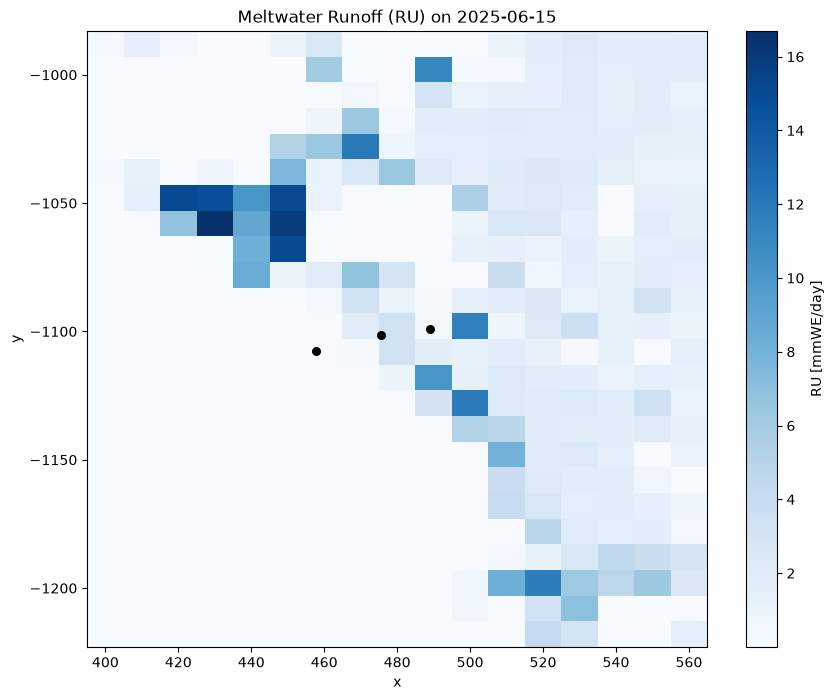

In [11]:
plot_date = "2025-06-15"

ru_day = meltwater_masked["RU"].sel(TIME=plot_date, method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on {plot_date}")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [13]:
meltwater_masked.to_netcdf('/Volumes/insar3/cjensen/Data/MAR/ftp.climato.be/fettweis/MARv3.14/Greenland/'+'meltwater2000_2025_daily.nc', mode='w')